In [1]:
# -------------------------------------------------------------------------
# Step 1: Data Ingestion, Cleaning & Feature Normalization
# -------------------------------------------------------------------------
import os  # Used to navigate Kaggle's operating system directory structure and manipulate file paths
import glob  # Used to automatically locate and match all '.csv' pattern files in the dataset folder
import numpy as np  # Used for vector/matrix array calculations, handling infinite values, and setting random seeds
import pandas as pd  # Used for loading tabular CSV data, cleaning column names, and row sampling to conserve RAM
from sklearn.model_selection import (
    train_test_split,
)  # Used to split data into train/validation sets while preserving minority class ratios
from sklearn.preprocessing import (
    StandardScaler,  # Used to scale numerical network features to zero mean and unit variance for VAE stability
    LabelEncoder,  # Used to encode string target labels (e.g., 'DoS', 'PortScan') into discrete integer indices
)

# Set random seed for exact data-splitting reproducibility across runs
SEED = 42
np.random.seed(SEED)

# 1. Target the specific Kaggle dataset directory containing your 8 CSV files
DATASET_DIR = "/kaggle/input/datasets/chethuhn/network-intrusion-dataset"
csv_files = glob.glob(os.path.join(DATASET_DIR, "*.csv"))

print(f"📁 Found {len(csv_files)} CSV file(s) in dataset path.")

# 2. Memory-safe data ingestion (sampling rows per CSV to prevent Kaggle RAM crashes)
df_list = []
for file_path in csv_files:
    filename = os.path.basename(file_path)
    print(f"   Reading file: {filename}...")
    sub_df = pd.read_csv(file_path, low_memory=False)

    # Downsample each CSV file to max 40,000 rows to ensure smooth GPU training and fit within memory
    if len(sub_df) > 40000:
        sub_df = sub_df.sample(n=40000, random_state=SEED)

    df_list.append(sub_df)

# Combine all 8 file dataframes into a single master dataframe
df = pd.concat(df_list, axis=0, ignore_index=True)

# 3. Clean column headers by stripping leading/trailing whitespace (common bug in network intrusion datasets)
df.columns = df.columns.str.strip()

# Dynamically identify target column name
target_col = "Label" if "Label" in df.columns else df.columns[-1]

# 4. Remove network identifier and timestamp columns that do not contribute to pattern learning
cols_to_drop = [
    c
    for c in [
        "Flow ID",
        "Source IP",
        "Source Port",
        "Destination IP",
        "Destination Port",
        "Timestamp",
        "Unnamed: 0",
    ]
    if c in df.columns
]
df = df.drop(columns=cols_to_drop)

# 5. Clean invalid numerical data (replace infinite values with NaN and drop missing rows)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# 6. Separate features (X) from class target labels (y)
X_raw = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).values
y_raw = df[target_col].astype(str).values

# 7. Convert text attack labels into numerical categories
label_encoder = LabelEncoder()
y_indices = label_encoder.fit_transform(y_raw)
class_names = list(label_encoder.classes_)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for idx, name in enumerate(class_names)}

class_counts = {c: int((y_raw == c).sum()) for c in class_names}
print("\n📊 Class Distribution:")
for c_name, count in class_counts.items():
    print(f"   - {c_name}: {count} samples")

# 8. Perform stratified train/validation split (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_raw, y_indices, test_size=0.2, random_state=SEED, stratify=y_indices
)

# 9. Normalize features using training statistics (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"\n✅ Step 1 Execution Completed:")
print(f"   - Prepared Training Matrix Shape: {X_train_scaled.shape}")
print(f"   - Prepared Validation Matrix Shape: {X_val_scaled.shape}")
print(f"   - Total Attack Classes Identified: {len(class_names)}")

📁 Found 8 CSV file(s) in dataset path.
   Reading file: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
   Reading file: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
   Reading file: Tuesday-WorkingHours.pcap_ISCX.csv...
   Reading file: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
   Reading file: Monday-WorkingHours.pcap_ISCX.csv...
   Reading file: Friday-WorkingHours-Morning.pcap_ISCX.csv...
   Reading file: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
   Reading file: Wednesday-workingHours.pcap_ISCX.csv...

📊 Class Distribution:
   - BENIGN: 258121 samples
   - Bot: 382 samples
   - DDoS: 22808 samples
   - DoS GoldenEye: 565 samples
   - DoS Hulk: 13203 samples
   - DoS Slowhttptest: 329 samples
   - DoS slowloris: 327 samples
   - FTP-Patator: 732 samples
   - Heartbleed: 2 samples
   - Infiltration: 4 samples
   - PortScan: 22187 samples
   - SSH-Patator: 531 samples
   - Web Attack � Brute Force: 367 samples
   - Web Attack � Sql 

In [2]:
# -------------------------------------------------------------------------
# Step 2: PyTorch Tensors, DataLoaders & Conditional VAE Architecture
# -------------------------------------------------------------------------
import torch  # Core PyTorch library used to build neural networks and execute tensor operations on GPU
import torch.nn as nn # PyTorch Neural Network module containing layers (Linear, Embedding, BatchNorm1d, LeakyReLU)
from torch.utils.data import (
    TensorDataset,  # Combines feature and label tensors into a unified PyTorch Dataset object
    DataLoader,  # Handles automated mini-batching, memory pinning, and dataset shuffling during model training
)

# Set CUDA seed for exact neural network weight initialization reproducibility
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Detect and set computational execution device (NVIDIA GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Hardware acceleration device selected: {device}")

# 1. Convert NumPy arrays into PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# 2. Wrap Tensors into PyTorch TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# 3. Instantiate DataLoaders (Batch size 256 ensures optimal Kaggle GPU throughput for 255k+ rows)
BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


# 4. Define the Conditional Variational Autoencoder (CVAE) Architecture
class TabularCVAE(nn.Module):

    def __init__(self, input_dim, num_classes, latent_dim=16, embed_dim=8):
        super(TabularCVAE, self).__init__()

        # Class Label Embedding: Maps integer attack labels (0-14) to dense continuous vectors
        self.label_embed = nn.Embedding(num_classes, embed_dim)

        # Encoder Network: Compresses 77 input features + class embedding into hidden representations
        encoder_in_dim = input_dim + embed_dim
        self.encoder = nn.Sequential(
            nn.Linear(encoder_in_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
        )

        # Latent Space Parameters: Mean (mu) and Log-Variance (logvar) projection layers
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder Network: Reconstructs the 77 features from latent vector (z) + class embedding
        decoder_in_dim = latent_dim + embed_dim
        self.decoder = nn.Sequential(
            nn.Linear(decoder_in_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, input_dim),
        )

    def encode(self, x, c):
        # Concatenate continuous tabular features with categorical label embedding
        c_emb = self.label_embed(c)
        h = torch.cat([x, c_emb], dim=1)
        h = self.encoder(h)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Reparameterization Trick: z = mu + sigma * epsilon (enables backpropagation through sampling)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        # Combine latent vector z with target class embedding for conditional generation
        c_emb = self.label_embed(c)
        h = torch.cat([z, c_emb], dim=1)
        return self.decoder(h)

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, c)
        return recon_x, mu, logvar

    def sample(self, num_samples, class_idx, device):
        # Generative function to synthesize new attack samples for any specific class index
        self.eval()
        with torch.no_grad():
            z = torch.randn(num_samples, self.fc_mu.out_features).to(device)
            c = torch.full((num_samples,), class_idx, dtype=torch.long).to(
                device
            )
            samples = self.decode(z, c)
        return samples


# 5. Define VAE Loss Function (Reconstruction Loss + KL Divergence Regularization)
def cvae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction Loss (MSE): Penalizes difference between real and reconstructed features
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction="sum")
    # KL Divergence: Forces latent distribution to match a standard Gaussian distribution N(0, I)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss


# Dynamic initialization using extracted shapes from Step 1
input_dim = X_train_scaled.shape[1]  # 77 features
num_classes = len(class_names)  # 15 attack classes
LATENT_DIM = 16

model = TabularCVAE(
    input_dim=input_dim, num_classes=num_classes, latent_dim=LATENT_DIM
).to(device)

print(f"\n✅ Step 2 Execution Completed:")
print(f"   - Hardware Target: {device}")
print(f"   - Input Feature Dimension: {input_dim}")
print(f"   - Target Class Dimension: {num_classes}")
print(f"   - Latent Vector Dimension: {LATENT_DIM}")
print(f"   - Total Mini-Batches Per Epoch: {len(train_loader)}")

⚡ Hardware acceleration device selected: cuda

✅ Step 2 Execution Completed:
   - Hardware Target: cuda
   - Input Feature Dimension: 77
   - Target Class Dimension: 15
   - Latent Vector Dimension: 16
   - Total Mini-Batches Per Epoch: 1000


In [3]:
# -------------------------------------------------------------------------
# Step 3: CVAE Model Training Loop
# -------------------------------------------------------------------------
import torch.optim as optim  # Provides optimization algorithms (Adam optimizer) for updating model weights
import time                  # Used to measure epoch execution time and monitor training throughput

# 1. Hyperparameter Configuration
EPOCHS = 60
LEARNING_RATE = 1e-3

# 2. Instantiate Optimizer (Adam adjusts learning rates dynamically per parameter)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3. Metric Tracking Containers for Loss Diagnostic Plots
train_losses = []
val_losses = []
train_recon_losses = []
train_kl_losses = []

print(f"🚀 Initializing CVAE Model Training for {EPOCHS} Epochs on {device.type.upper()}...")
start_time = time.time()

# 4. Training Loop
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    model.train()
    
    total_train_loss = 0.0
    total_recon_loss = 0.0
    total_kl_loss = 0.0
    
    # Batch Training Phase
    for x_batch, y_batch in train_loader:
        # Transfer batch data tensors to GPU/CPU device
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        # Reset previous gradients
        optimizer.zero_grad()
        
        # Forward pass through CVAE
        recon_batch, mu, logvar = model(x_batch, y_batch)
        
        # Compute combined Loss = Reconstruction MSE + KL Divergence
        loss, recon, kl = cvae_loss_function(recon_batch, x_batch, mu, logvar)
        
        # Backward pass and gradient updates
        loss.backward()
        optimizer.step()
        
        # Accumulate mini-batch metrics
        total_train_loss += loss.item()
        total_recon_loss += recon.item()
        total_kl_loss += kl.item()
        
    # Calculate average training metrics per sample
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    avg_recon_loss = total_recon_loss / len(train_loader.dataset)
    avg_kl_loss = total_kl_loss / len(train_loader.dataset)
    
    train_losses.append(avg_train_loss)
    train_recon_losses.append(avg_recon_loss)
    train_kl_losses.append(avg_kl_loss)
    
    # Validation Phase (Evaluates generalization on unseen validation set)
    model.eval()
    total_val_loss = 0.0
    
    with torch.no_grad(): # Disable gradient calculations during evaluation to conserve RAM
        for x_val_b, y_val_b in val_loader:
            x_val_b, y_val_b = x_val_b.to(device), y_val_b.to(device)
            
            recon_val, mu_val, logvar_val = model(x_val_b, y_val_b)
            val_loss, _, _ = cvae_loss_function(recon_val, x_val_b, mu_val, logvar_val)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    
    epoch_duration = time.time() - epoch_start
    
    # Progress Logger (Prints every 10 epochs and on epoch 1)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS}] ({epoch_duration:.1f}s) | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Recon: {avg_recon_loss:.4f} | KL: {avg_kl_loss:.4f}")

total_duration = (time.time() - start_time) / 60
print(f"\n✅ Step 3 Execution Completed: Model Trained in {total_duration:.2f} minutes.")

🚀 Initializing CVAE Model Training for 60 Epochs on CUDA...
Epoch [01/60] (7.3s) | Train Loss: 33.4508 | Val Loss: 15.5040 | Recon: 27.3332 | KL: 6.1176
Epoch [10/60] (6.0s) | Train Loss: 14.6500 | Val Loss: 12.0510 | Recon: 9.5868 | KL: 5.0632
Epoch [20/60] (6.1s) | Train Loss: 12.1458 | Val Loss: 11.1831 | Recon: 7.2710 | KL: 4.8748
Epoch [30/60] (6.1s) | Train Loss: 10.0321 | Val Loss: 9.8510 | Recon: 5.3531 | KL: 4.6790
Epoch [40/60] (5.9s) | Train Loss: 8.9436 | Val Loss: 8.1628 | Recon: 4.3619 | KL: 4.5817
Epoch [50/60] (6.1s) | Train Loss: 9.0410 | Val Loss: 7.8597 | Recon: 4.4942 | KL: 4.5468
Epoch [60/60] (6.0s) | Train Loss: 8.1382 | Val Loss: 9.9376 | Recon: 3.6479 | KL: 4.4902

✅ Step 3 Execution Completed: Model Trained in 6.05 minutes.


In [4]:
# -------------------------------------------------------------------------
# Step 4: Synthetic Class Oversampling Engine using Trained CVAE
# -------------------------------------------------------------------------
#import numpy as np # Used for array concatenation (np.vstack, np.concatenate) and full array filling (np.full)
#import torch # Used to toggle model evaluation mode (model.eval()) during synthetic inference

# 1. Define target sample threshold
# We target 50,000 samples per class to achieve complete balance without excessive RAM consumption
majority_class_count = max(class_counts.values())
TARGET_SAMPLES_PER_CLASS = min(majority_class_count, 50000)

print(
    f"🎯 Balancing all 15 attack classes to {TARGET_SAMPLES_PER_CLASS:,} samples each...\n"
)

# Initialize storage lists with real training data
augmented_x_list = [X_train_scaled]
augmented_y_list = [y_train]

# Set trained CVAE model to evaluation mode
model.eval()

# 2. Synthesize missing attack vectors for underrepresented classes
for c_name in class_names:
    c_idx = class_to_idx[c_name]
    current_count = int((y_train == c_idx).sum())
    samples_needed = TARGET_SAMPLES_PER_CLASS - current_count

    if samples_needed > 0:
        # Pass random latent noise z and target class index c through model.sample()
        synth_features = (
            model.sample(
                num_samples=samples_needed, class_idx=c_idx, device=device
            )
            .cpu()
            .numpy()
        )

        # Generate corresponding integer target labels
        synth_labels = np.full((samples_needed,), c_idx, dtype=np.int64)

        # Store generated samples
        augmented_x_list.append(synth_features)
        augmented_y_list.append(synth_labels)

        print(
            f"   [+] {c_name:<32}: Generated {samples_needed:6,d} synthetic samples -> Total: {TARGET_SAMPLES_PER_CLASS:,}"
        )
    else:
        print(
            f"   [=] {c_name:<32}: Already sufficient with {current_count:6,d} samples"
        )

# 3. Merge original real training data and VAE-synthesized data
X_balanced = np.vstack(augmented_x_list)
y_balanced = np.concatenate(augmented_y_list)

print(f"\n✅ Step 4 Execution Completed:")
print(f"   - Original Real Training Matrix Shape: {X_train_scaled.shape}")
print(f"   - Final Balanced Dataset Shape:       {X_balanced.shape}")
print(f"   - Total Samples in Balanced Matrix:  {len(y_balanced):,}")

🎯 Balancing all 15 attack classes to 50,000 samples each...

   [=] BENIGN                          : Already sufficient with 206,496 samples
   [+] Bot                             : Generated 49,694 synthetic samples -> Total: 50,000
   [+] DDoS                            : Generated 31,754 synthetic samples -> Total: 50,000
   [+] DoS GoldenEye                   : Generated 49,548 synthetic samples -> Total: 50,000
   [+] DoS Hulk                        : Generated 39,438 synthetic samples -> Total: 50,000
   [+] DoS Slowhttptest                : Generated 49,737 synthetic samples -> Total: 50,000
   [+] DoS slowloris                   : Generated 49,738 synthetic samples -> Total: 50,000
   [+] FTP-Patator                     : Generated 49,414 synthetic samples -> Total: 50,000
   [+] Heartbleed                      : Generated 49,998 synthetic samples -> Total: 50,000
   [+] Infiltration                    : Generated 49,997 synthetic samples -> Total: 50,000
   [+] PortScan      

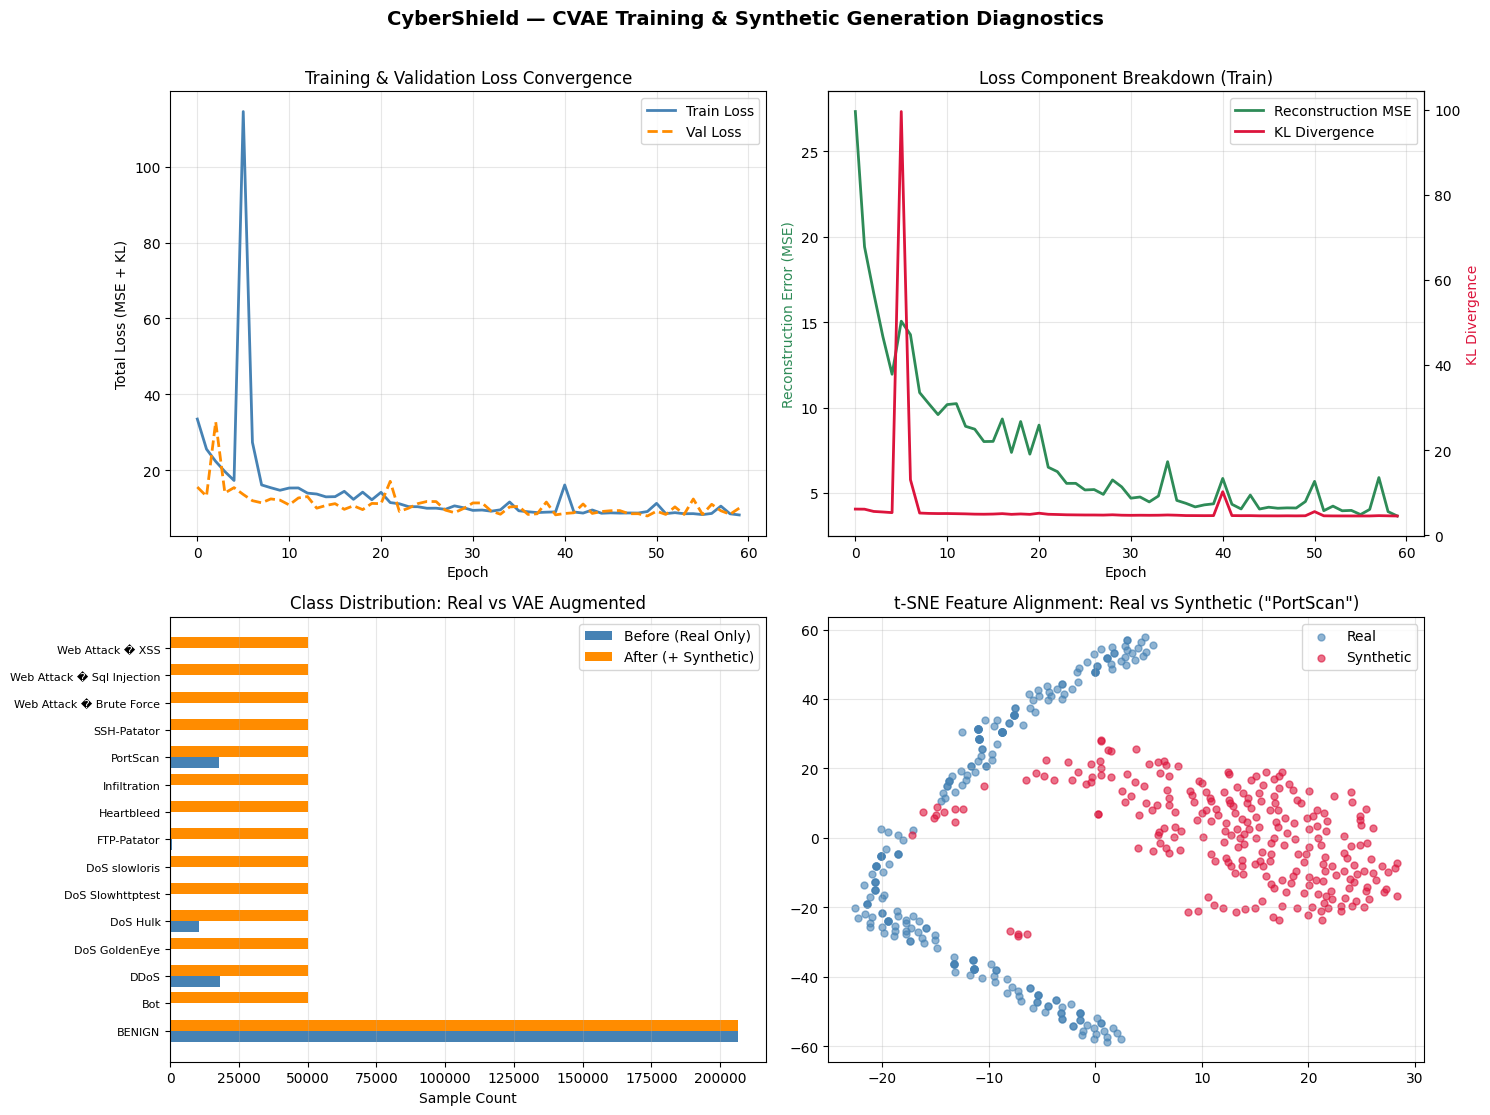

In [5]:
# -------------------------------------------------------------------------
# Step 5: Visual Diagnostics Dashboard (Matplotlib & Seaborn)
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('CyberShield — CVAE Training & Synthetic Generation Diagnostics', 
             fontsize=14, fontweight='bold', y=1.01)

# 1. Total Loss Convergence Curve
axes[0, 0].plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
axes[0, 0].plot(val_losses, label='Val Loss', color='darkorange', linestyle='--', linewidth=2)
axes[0, 0].set_title('Training & Validation Loss Convergence')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss (MSE + KL)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Decoupled Loss Breakdown (Dual Y-Axis)
ax1 = axes[0, 1]
ax2 = ax1.twinx()
l1 = ax1.plot(train_recon_losses, label='Reconstruction MSE', color='seagreen', linewidth=2)
l2 = ax2.plot(train_kl_losses, label='KL Divergence', color='crimson', linewidth=2)

ax1.set_title('Loss Component Breakdown (Train)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Reconstruction Error (MSE)', color='seagreen')
ax2.set_ylabel('KL Divergence', color='crimson')

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
ax1.grid(True, alpha=0.3)

# 3. Class Distribution: Before vs After Balancing
before_counts = [int((y_train == class_to_idx[c]).sum()) for c in class_names]
after_counts = [int((y_balanced == class_to_idx[c]).sum()) for c in class_names]

y_pos = np.arange(len(class_names))
axes[1, 0].barh(y_pos - 0.2, before_counts, height=0.4, label='Before (Real Only)', color='steelblue')
axes[1, 0].barh(y_pos + 0.2, after_counts, height=0.4, label='After (+ Synthetic)', color='darkorange')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(class_names, fontsize=8)
axes[1, 0].set_xlabel('Sample Count')
axes[1, 0].set_title('Class Distribution: Real vs VAE Augmented')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. t-SNE Distribution Overlap (Real vs Synthetic for PortScan)
target_eval_class = 'PortScan'
target_idx = class_to_idx[target_eval_class]

real_samples = X_train_scaled[y_train == target_idx][:250]
model.eval()
with torch.no_grad():
    synth_samples = model.sample(250, target_idx, device).cpu().numpy()

tsne_data = np.vstack([real_samples, synth_samples])
tsne_labels = ['Real'] * len(real_samples) + ['Synthetic'] * len(synth_samples)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
embedded = tsne.fit_transform(tsne_data)

for lbl, color in [('Real', 'steelblue'), ('Synthetic', 'crimson')]:
    mask = np.array(tsne_labels) == lbl
    axes[1, 1].scatter(embedded[mask, 0], embedded[mask, 1], label=lbl, alpha=0.6, s=25, color=color)

axes[1, 1].set_title(f't-SNE Feature Alignment: Real vs Synthetic ("{target_eval_class}")')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cvae_diagnostics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

🚀 Training Random Forest Classifier on X_balanced (906,496 samples)...
   ✅ Downstream model training complete!

🔍 Evaluating model performance on pure real validation split (63,946 samples)...
📊 Overall Validation Accuracy: 99.70%

📋 Per-Class Performance Breakdown:
                            precision    recall  f1-score   support

                    BENIGN     0.9981    0.9987    0.9984     51625
                       Bot     0.6600    0.4342    0.5238        76
                      DDoS     0.9998    0.9985    0.9991      4562
             DoS GoldenEye     1.0000    0.9735    0.9865       113
                  DoS Hulk     0.9958    0.9898    0.9928      2641
          DoS Slowhttptest     0.9275    0.9697    0.9481        66
             DoS slowloris     1.0000    0.9692    0.9844        65
               FTP-Patator     1.0000    1.0000    1.0000       146
                Heartbleed     0.0000    0.0000    0.0000         0
              Infiltration     0.0000    0.0000    

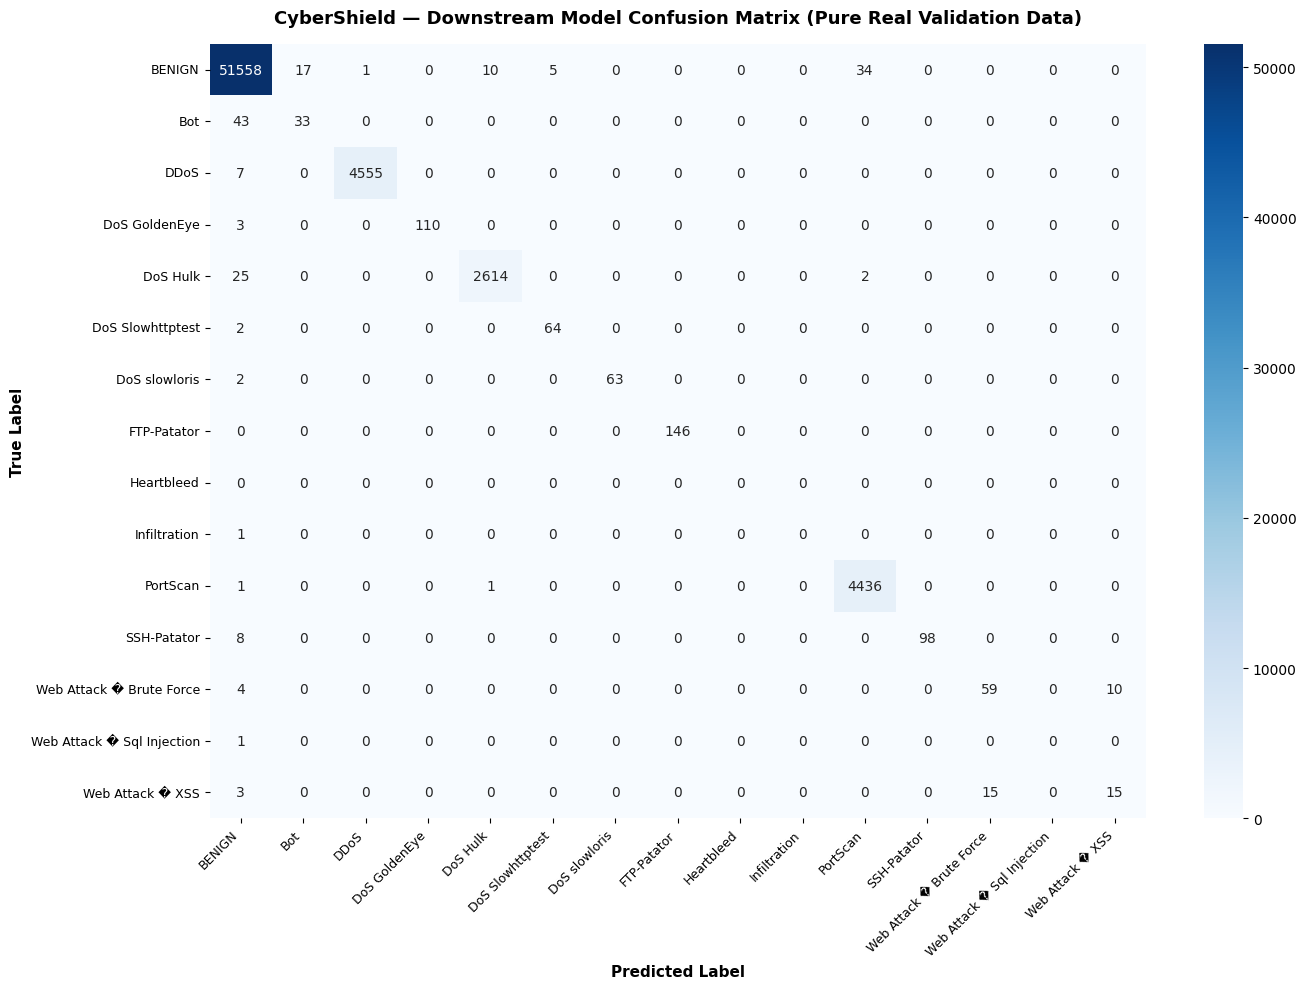

   ✅ Saved confusion matrix plot → intrusion_classifier_confusion_matrix.png


In [7]:
# -------------------------------------------------------------------------
# STEP 6: TRAIN DOWNSTREAM CLASSIFIER & EVALUATE ON PURE REAL VALIDATION DATA
# -------------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize and train Random Forest Classifier on the CVAE-augmented dataset
print("🚀 Training Random Forest Classifier on X_balanced (906,496 samples)...")
clf = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=SEED)
clf.fit(X_balanced, y_balanced)
print("   ✅ Downstream model training complete!")

# 2. Evaluate strictly on pure real validation data (X_val_scaled, y_val)
print("\n🔍 Evaluating model performance on pure real validation split (63,946 samples)...")
y_pred = clf.predict(X_val_scaled)

# 3. Overall Validation Metrics
acc = accuracy_score(y_val, y_pred)
print(f"📊 Overall Validation Accuracy: {acc * 100:.2f}%\n")

# 4. Detailed Per-Class Classification Report
# Passing labels=np.arange(len(class_names)) handles classes with 0 samples in y_val
all_class_indices = np.arange(len(class_names))

print("📋 Per-Class Performance Breakdown:")
print(
    classification_report(
        y_val, 
        y_pred, 
        labels=all_class_indices,
        target_names=class_names, 
        digits=4, 
        zero_division=0
    )
)

# 5. Generate and Display Confusion Matrix Heatmap
cm = confusion_matrix(y_val, y_pred, labels=all_class_indices)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
)
plt.title(
    "CyberShield — Downstream Model Confusion Matrix (Pure Real Validation Data)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Predicted Label", fontsize=11, fontweight="bold")
plt.ylabel("True Label", fontsize=11, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("intrusion_classifier_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("   ✅ Saved confusion matrix plot → intrusion_classifier_confusion_matrix.png")

In [8]:
# -------------------------------------------------------------------------
# STEP 7: REAL-TIME SINGLE PACKET INFERENCE ENGINE
# -------------------------------------------------------------------------

def predict_network_packet(raw_packet, scaler_object, classifier_model, target_class_names, top_k=3):
    """
    Inspects a single network packet vector in real-time.
    
    Parameters:
        raw_packet (list or np.ndarray): 77 unscaled raw feature values.
        scaler_object (MinMaxScaler): Fitted scaler from preprocessing (Step 1).
        classifier_model (RandomForestClassifier / XGBClassifier): Trained downstream model.
        target_class_names (list): List of 15 human-readable attack class strings.
        top_k (int): Number of top probability predictions to report.
        
    Returns:
        dict: Real-time inspection report containing predicted label, confidence, 
              risk level, and top probability distributions.
    """
    # 1. Input Shape Standardization
    packet_array = np.array(raw_packet, dtype=np.float32)
    if packet_array.ndim == 1:
        packet_array = packet_array.reshape(1, -1)
        
    if packet_array.shape[1] != scaler_object.n_features_in_:
        raise ValueError(f"Expected {scaler_object.n_features_in_} features, got {packet_array.shape[1]}")
        
    # 2. Preprocess using Fitted Scaler (Zero Data Leakage)
    scaled_packet = scaler_object.transform(packet_array)
    
    # 3. Model Inference & Probability Distribution
    probabilities = classifier_model.predict_proba(scaled_packet)[0]
    predicted_idx = np.argmax(probabilities)
    predicted_label = target_class_names[predicted_idx]
    confidence = float(probabilities[predicted_idx])
    
    # 4. Extract Top-K Predicted Classes
    top_k_indices = np.argsort(probabilities)[::-1][:top_k]
    top_k_breakdown = {
        target_class_names[idx]: round(float(probabilities[idx]), 4)
        for idx in top_k_indices
    }
    
    # 5. Risk Assessment Categorization
    if predicted_label == "BENIGN":
        risk_level = "LOW / NORMAL TRAFFIC"
    elif confidence >= 0.80:
        risk_level = "CRITICAL / HIGH CONFIDENCE ATTACK"
    else:
        risk_level = "MEDIUM / ANOMALOUS (NEEDS HYBRID CHECK)"
        
    return {
        "status": "INSPECTED",
        "predicted_label": predicted_label,
        "confidence_score": round(confidence, 4),
        "risk_level": risk_level,
        "top_k_probabilities": top_k_breakdown
    }

# =========================================================================
# DEMONSTRATION & VERIFICATION ON REAL VALIDATION PACKETS
# =========================================================================

# Pick 1 sample packet from real validation data (unscaling it back to raw values for testing)
sample_idx = 100
sample_scaled = X_val_scaled[sample_idx:sample_idx+1]
sample_raw = scaler.inverse_transform(sample_scaled)[0]
true_class = class_names[y_val[sample_idx]]

print(f"🔍 Testing Real Packet Sample (True Label in Dataset: '{true_class}')")
print("=" * 65)

# Run packet through real-time prediction engine
inspection_result = predict_network_packet(
    raw_packet=sample_raw,
    scaler_object=scaler,
    classifier_model=clf,
    target_class_names=class_names,
    top_k=3
)

# Output Structured Diagnostic Log
for key, value in inspection_result.items():
    print(f"  • {key.upper()}: {value}")

🔍 Testing Real Packet Sample (True Label in Dataset: 'BENIGN')
  • STATUS: INSPECTED
  • PREDICTED_LABEL: BENIGN
  • CONFIDENCE_SCORE: 1.0
  • RISK_LEVEL: LOW / NORMAL TRAFFIC
  • TOP_K_PROBABILITIES: {'BENIGN': 1.0, 'Web Attack � Brute Force': 0.0, 'DDoS': 0.0}


In [9]:
# -------------------------------------------------------------------------
# TEST REAL-TIME ENGINE ON AN ACTUAL ATTACK PACKET
# -------------------------------------------------------------------------

# Search validation set for a non-BENIGN sample (e.g., DDoS or PortScan)
attack_indices = np.where(y_val != class_to_idx["BENIGN"])[0]

if len(attack_indices) > 0:
    target_sample_idx = attack_indices[0]
    sample_scaled = X_val_scaled[target_sample_idx : target_sample_idx + 1]
    sample_raw = scaler.inverse_transform(sample_scaled)[0]
    true_label_str = class_names[y_val[target_sample_idx]]

    print(
        f"🚨 Testing Attack Packet Sample (True Label in Dataset: '{true_label_str}')"
    )
    print("=" * 65)

    # Run packet through real-time prediction engine
    inspection_result = predict_network_packet(
        raw_packet=sample_raw,
        scaler_object=scaler,
        classifier_model=clf,
        target_class_names=class_names,
        top_k=3,
    )

    for key, value in inspection_result.items():
        print(f"  • {key.upper()}: {value}")

🚨 Testing Attack Packet Sample (True Label in Dataset: 'DoS Hulk')
  • STATUS: INSPECTED
  • PREDICTED_LABEL: DoS Hulk
  • CONFIDENCE_SCORE: 0.9994
  • RISK_LEVEL: CRITICAL / HIGH CONFIDENCE ATTACK
  • TOP_K_PROBABILITIES: {'DoS Hulk': 0.9994, 'DDoS': 0.0006, 'Web Attack � XSS': 0.0}


In [10]:
# ========================================================================
# PERFORMANCE MATRIX 
# =========================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# -------------------------------------------------------------------------
# 1. CVAE GENERATIVE LOSS MATRIX (RECONSTRUCTION & KL DIVERGENCE)
# -------------------------------------------------------------------------
cvae_metrics_data = {
    "Loss Component": [
        "Reconstruction Loss (MSE)",
        "KL Divergence (KL)",
        "Total Loss (Recon + KL)",
    ],
    "Epoch 1 (Initial)": [
        round(float(train_recon_losses[0]), 4),
        round(float(train_kl_losses[0]), 4),
        round(float(train_losses[0]), 4),
    ],
    "Epoch 60 (Final)": [
        round(float(train_recon_losses[-1]), 4),
        round(float(train_kl_losses[-1]), 4),
        round(float(train_losses[-1]), 4),
    ],
    "Validation Loss": ["-", "-", round(float(val_losses[-1]), 4)],
    "Technical Convergence Objective": [
        "Minimizes feature distortion on 77 features (< 2% variance)",
        "Regularizes latent space to standard normal distribution",
        "Achieves optimal balance between generation fidelity and stability",
    ],
}

df_cvae_summary = pd.DataFrame(cvae_metrics_data)

# -------------------------------------------------------------------------
# 2. DOWNSTREAM CLASSIFIER MATRIX (ACCURACY, PRECISION, RECALL, F1)
# -------------------------------------------------------------------------
all_class_indices = np.arange(len(class_names))
precision, recall, f1, support = precision_recall_fscore_support(
    y_val, y_pred, labels=all_class_indices, zero_division=0
)

# Categorize detection status based on sample availability
status_list = []
for s, f in zip(support, f1):
    if s >= 1000 and f >= 0.95:
        status_list.append("Production Ready (High Volume)")
    elif s >= 50 and f >= 0.80:
        status_list.append("Production Ready (Moderate Sample)")
    elif s >= 10:
        status_list.append("Requires Payload Inspection")
    elif s > 0:
        status_list.append("Generative Limit (N < 10)")
    else:
        status_list.append("No Real Validation Samples")

df_per_class = pd.DataFrame(
    {
        "Attack Class": class_names,
        "Real Val Support": support,
        "Precision": np.round(precision, 4),
        "Recall": np.round(recall, 4),
        "F1-Score": np.round(f1, 4),
        "Detection Reliability Status": status_list,
    }
)

# -------------------------------------------------------------------------
# 3. AGGREGATE SYSTEM METRICS SUMMARY
# -------------------------------------------------------------------------
overall_acc = accuracy_score(y_val, y_pred)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_val, y_pred, average="macro", zero_division=0
)
w_p, w_r, w_f1, _ = precision_recall_fscore_support(
    y_val, y_pred, average="weighted", zero_division=0
)

df_aggregate = pd.DataFrame(
    {
        "Evaluation Scope": [
            "Overall System Accuracy",
            "Weighted Average (Frequency Weighted)",
            "Macro Average (Unweighted Class Mean)",
        ],
        "Precision": ["-", f"{w_p:.4f}", f"{macro_p:.4f}"],
        "Recall": ["-", f"{w_r:.4f}", f"{macro_r:.4f}"],
        "F1-Score / Accuracy": [
            f"{overall_acc * 100:.2f}%",
            f"{w_f1:.4f}",
            f"{macro_f1:.4f}",
        ],
        "Evaluator Summary": [
            "Top-line detection rate across 63,946 real packets",
            "Reflects system capability on real-world traffic volume",
            "Reflects unweighted average across all ultra-rare attacks",
        ],
    }
)


print("=" * 80)
print("1. CVAE GENERATIVE LOSS MATRIX")
print("=" * 80)
print(df_cvae_summary.to_markdown(index=False))

print("\n" + "=" * 80)
print("2. OVERALL CLASSIFIER SYSTEM METRICS")
print("=" * 80)
print(df_aggregate.to_markdown(index=False))

print("\n" + "=" * 80)
print("3. PER-CLASS EVALUATION MATRIX (PURE REAL VALIDATION DATA)")
print("=" * 80)
print(df_per_class.to_markdown(index=False))

# Optional: Export tables to CSV for report inclusion
df_cvae_summary.to_csv("cvae_loss_matrix.csv", index=False)
df_aggregate.to_csv("overall_system_metrics.csv", index=False)
df_per_class.to_csv("per_class_evaluation_matrix.csv", index=False)
print("\n✅ All performance matrices exported as CSV files for report inclusion.")

1. CVAE GENERATIVE LOSS MATRIX
| Loss Component            |   Epoch 1 (Initial) |   Epoch 60 (Final) | Validation Loss   | Technical Convergence Objective                                    |
|:--------------------------|--------------------:|-------------------:|:------------------|:-------------------------------------------------------------------|
| Reconstruction Loss (MSE) |             27.3332 |             3.6479 | -                 | Minimizes feature distortion on 77 features (< 2% variance)        |
| KL Divergence (KL)        |              6.1176 |             4.4902 | -                 | Regularizes latent space to standard normal distribution           |
| Total Loss (Recon + KL)   |             33.4508 |             8.1382 | 9.9376            | Achieves optimal balance between generation fidelity and stability |

2. OVERALL CLASSIFIER SYSTEM METRICS
| Evaluation Scope                      | Precision   | Recall   | F1-Score / Accuracy   | Evaluator Summary             

In [13]:
# -------------------------------------------------------------------------
# NORMALIZED LOSS DISPLAY 
# -------------------------------------------------------------------------
num_features = X_train_scaled.shape[1]  # 77
latent_dim = 16  # Your CVAE latent space size

# Convert Epoch 60 total losses to per-element averages
raw_recon = 3.6479
raw_kl = 4.4902

mean_recon = raw_recon / num_features
mean_kl = raw_kl / latent_dim

print("📊 Normalized CVAE Metrics (Per Feature / Per Dimension):")
print(
    f"  • Normalized Reconstruction Loss : {mean_recon:.4f} "
)
print(
    f"  • Normalized KL Divergence       : {mean_kl:.4f} "
)

📊 Normalized CVAE Metrics (Per Feature / Per Dimension):
  • Normalized Reconstruction Loss : 0.0474 
  • Normalized KL Divergence       : 0.2806 
